<a href="https://colab.research.google.com/github/avikedare230455-cmd/ML/blob/main/Linear(Fuel%20vs%20CO2)---HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/avikedare230455-cmd/PYTHON-/refs/heads/main/FuelVsCO2.csv"

df = pd.read_csv(url)

print(df.head())

   Fuel_L_per_100km  CO2_g_per_km
0               3.5            90
1               3.6            92
2               3.7            94
3               3.8            96
4               3.9            98


In [6]:
X = df.iloc[:, 0].values
y = df.iloc[:, 1].values

# Convert to list (important for your model)
X = X.tolist()
y = y.tolist()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


In [15]:
# ==============================
class MyLinearRegression:
    def __init__(self, weight=2, bias=4, learning_rate=0.0005, iterations=2000):
        self.weight = weight
        self.bias = bias
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.cost_trend = []
        self.cost = 0

    def predict(self, x):
        return [self.weight * xi + self.bias for xi in x]

    def cost_function(self, x, y):
        n = len(x)
        error = 0
        for i in range(n):
            error += (y[i] - (self.weight * x[i] + self.bias)) ** 2
        return error / (2 * n)

    def update_weights(self, x, y):
        n = len(x)
        dw, db = 0, 0

        for i in range(n):
            pred = self.weight * x[i] + self.bias
            dw += -2 * x[i] * (y[i] - pred)
            db += -2 * (y[i] - pred)

        self.weight -= (dw / n) * self.learning_rate
        self.bias -= (db / n) * self.learning_rate

    def train(self, x, y):
        for i in range(self.iterations):
            self.update_weights(x, y)
            self.cost = self.cost_function(x, y)
            self.cost_trend.append(self.cost)


            print(f"Iteration {i} | Cost: {self.cost:.4f}")


In [16]:
model = MyLinearRegression()
model.train(X_train, y_train)

print("\nFinal Weight:", model.weight)
print("Final Bias:", model.bias)

Iteration 0 | Cost: 18660.9515
Iteration 1 | Cost: 13973.8593
Iteration 2 | Cost: 10464.9029
Iteration 3 | Cost: 7837.9488
Iteration 4 | Cost: 5871.2989
Iteration 5 | Cost: 4398.9806
Iteration 6 | Cost: 3296.7399
Iteration 7 | Cost: 2471.5550
Iteration 8 | Cost: 1853.7857
Iteration 9 | Cost: 1391.2966
Iteration 10 | Cost: 1045.0568
Iteration 11 | Cost: 785.8461
Iteration 12 | Cost: 591.7890
Iteration 13 | Cost: 446.5088
Iteration 14 | Cost: 337.7450
Iteration 15 | Cost: 256.3189
Iteration 16 | Cost: 195.3589
Iteration 17 | Cost: 149.7208
Iteration 18 | Cost: 115.5533
Iteration 19 | Cost: 89.9731
Iteration 20 | Cost: 70.8218
Iteration 21 | Cost: 56.4834
Iteration 22 | Cost: 45.7481
Iteration 23 | Cost: 37.7103
Iteration 24 | Cost: 31.6920
Iteration 25 | Cost: 27.1855
Iteration 26 | Cost: 23.8109
Iteration 27 | Cost: 21.2835
Iteration 28 | Cost: 19.3906
Iteration 29 | Cost: 17.9725
Iteration 30 | Cost: 16.9099
Iteration 31 | Cost: 16.1136
Iteration 32 | Cost: 15.5165
Iteration 33 | Cost:

In [17]:
y_pred = model.predict(X_test)

In [13]:
print("\nCOMPARISON OF PREDICTED VS ACTUAL VALUES:")
print("----------------------------------------")

total_error = 0
best = float('inf')
worst = 0

for i in range(len(y_test)):
    diff = abs(y_pred[i] - y_test[i])
    total_error += diff
    best = min(best, diff)
    worst = max(worst, diff)

    print(f"Predicted: {y_pred[i]:.2f} | Actual: {y_test[i]:.2f} | Difference: {diff:.2f}")

print("----------------------------------------")
print(f"Average Error: {total_error/len(y_test):.2f}")
print(f"Best Prediction: {best:.2f} off")
print(f"Worst Prediction: {worst:.2f} off")



COMPARISON OF PREDICTED VS ACTUAL VALUES:
----------------------------------------
Predicted: 96.65 | Actual: 104.00 | Difference: 7.35
Predicted: 132.17 | Actual: 138.00 | Difference: 5.83
Predicted: 138.44 | Actual: 144.00 | Difference: 5.56
Predicted: 330.67 | Actual: 328.00 | Difference: 2.67
Predicted: 378.73 | Actual: 374.00 | Difference: 4.73
Predicted: 188.59 | Actual: 192.00 | Difference: 3.41
Predicted: 171.87 | Actual: 176.00 | Difference: 4.13
Predicted: 127.99 | Actual: 134.00 | Difference: 6.01
Predicted: 316.05 | Actual: 314.00 | Difference: 2.05
Predicted: 136.35 | Actual: 142.00 | Difference: 5.65
Predicted: 165.61 | Actual: 170.00 | Difference: 4.39
Predicted: 245.00 | Actual: 246.00 | Difference: 1.00
Predicted: 353.66 | Actual: 350.00 | Difference: 3.66
Predicted: 211.57 | Actual: 214.00 | Difference: 2.43
Predicted: 230.38 | Actual: 232.00 | Difference: 1.62
Predicted: 272.17 | Actual: 272.00 | Difference: 0.17
Predicted: 115.46 | Actual: 122.00 | Difference: 6.54

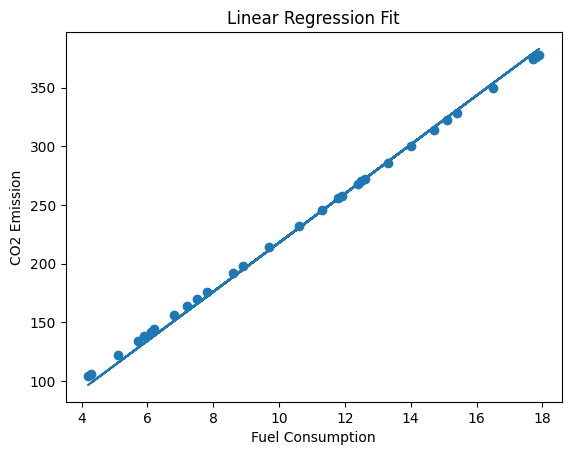

In [14]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Fuel Consumption")
plt.ylabel("CO2 Emission")
plt.title("Linear Regression Fit")
plt.show()

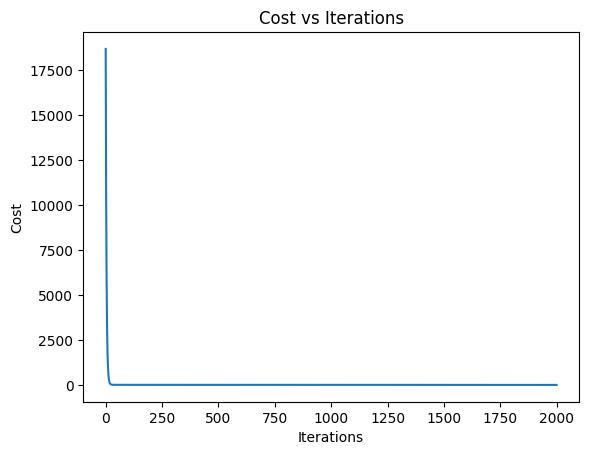

In [21]:
x = range(len(model.cost_trend))
y = model.cost_trend

plt.plot(x, y)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()